# SDG 3 (person B) Nformi Modestine: Feature engineering, baseline models & experiments


## How this Notebook connects to preprocessing (person A)

person A's script (`personA_eda_preprocessing.py`) produced two clean output files:

devex_train_clean.csv   ← training data with a new 'clean_text' column already preprocessed
devex_test_clean.csv    ← test data with a new 'clean_text' column already preprocessed


Person A's preprocessing pipeline already handled:
- HTML tag and entity removal
- Lowercasing
- Regex tokenization
- Stop word removal (NLTK English list)
- Lemmatization (WordNetLemmatizer)
- Domain acronym preservation (SDG, WHO, HIV, TB, USAID, etc.)
- Numeric-only token removal
- Label binarization into a label matrix

**Nformi Modestine(Person B) picks up from here.** i load the clean CSV files and go straight into feature engineering.



## What i take on in this Notebook

SECTION 0  — Install & Import

SECTION 1  — Load Person A's Cleaned Outputs

SECTION 2  — Reconstruct Labels & Split Data

SECTION 3  — Feature Engineering (Text → Numbers)

             3A: Bag of Words (BoW)
             3B: TF-IDF

SECTION 4  — Evaluation Metrics (defined once, reused everywhere)

SECTION 5  — Experiments

             Exp 1: LR + TF-IDF Unigrams  (Baseline)

             Exp 2: LR + TF-IDF Bigrams

             Exp 3: vocabulary Size Tuning

             Exp 4: model Comparison (LR vs SVM vs RF)

             Exp 5: threshold Optimization

             Exp 6: class Imbalance class_weight='balanced'


SECTION 6  — full results table + visualizations


SECTION 7  — final test predictions


---
# SECTION 0 Install & Import Libraries

In [39]:

!pip install scikit-learn pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd        
import numpy as np         
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,              
    accuracy_score,        
    classification_report  
)

print("all libraries installed")

all libraries installed


---
# SECTION 1 : Load preprocessing's cleaned outputs

Person A's script saved two ready-to-use files:
- `devex_train_clean.csv` original training data + a new `clean_text` column
- `devex_test_clean.csv`  original test data  + a new `clean_text` column

The `clean_text` column already has all preprocessing applied.  
We use that column directly, sono need to redo any of person A's work.

In [41]:

TRAIN_CLEAN_PATH = 'devex_train_clean.csv'
TEST_CLEAN_PATH  = 'devex_test_clean.csv'

LABEL_FREQ_PATH  = 'outputs/label_frequencies.csv'

train_df = pd.read_csv(TRAIN_CLEAN_PATH, encoding='latin-1', low_memory=False)

test_df  = pd.read_csv(TEST_CLEAN_PATH,  encoding='latin-1', low_memory=False)

print(f"Training rows: {len(train_df):,}")
print(f"Test rows:     {len(test_df):,}")
print(f"\nTraining columns ({len(train_df.columns)}):")
print(train_df.columns.tolist())

Training rows: 2,995
Test rows:     998

Training columns (16):
['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12', 'clean_text']


In [42]:
assert 'clean_text' in train_df.columns, \
    "ERROR: 'clean_text' column not found. Make sure you're loading Person A's OUTPUT file (devex_train_clean.csv), not the original."

assert 'clean_text' in test_df.columns, \
    "ERROR: 'clean_text' column not found in test file."

# preview: compare raw text vs Person A's cleaned text side by side
# this shows exactly what Person A's pipeline did
raw_col = [c for c in train_df.columns if 'text' in c.lower() and c != 'clean_text'][0]

print("=== COMPARISON: Raw text vs Person A's clean_text ===\n")
for i in range(2):
    print(f"--- Document {i} ---")
    print(f"RAW:   {str(train_df[raw_col].iloc[i])[:300]}")
    print(f"CLEAN: {str(train_df['clean_text'].iloc[i])[:300]}")
    print()
    
print("clean_text column confirmed.preprocessing works and is intact.")
RAW_TEXT_COL = raw_col  # saving this for reference

=== COMPARISON: Raw text vs Person A's clean_text ===

--- Document 0 ---
RAW:   Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not 
CLEAN: center biomedical research excellence cobre phase iii transitional center funding opportunity description institutional development award idea program endeavor stimulate research institution state traditionally received significant level research funding nih created congressional mandate idea progra

--- Document 1 ---
RAW:   Research on Regenerative Medicine <h2><strong>Introduction</strong></h2>    <p>Supports translation of fundamental discoveries toward benefits to human health.</p>    <p>The translation of the burgeoning knowledge in regenerative medicine into new treatment strategies is a key objec

In [43]:
# we double-check if initial preprocessing handles handles empty strings
missing_train = train_df['clean_text'].isna().sum()
missing_test  = test_df['clean_text'].isna().sum()
print(f"Missing clean_text values — train: {missing_train}, test: {missing_test}")

train_df['clean_text'] = train_df['clean_text'].fillna('')
test_df['clean_text']  = test_df['clean_text'].fillna('')


before = len(train_df)
train_df = train_df[train_df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"Dropped {before - len(train_df)} empty documents. Remaining: {len(train_df):,}")

Missing clean_text values — train: 0, test: 0
Dropped 0 empty documents. Remaining: 2,995


---
# SECTION 2 : Reconstruct Labels & Split Data

Preprocessing  used `detect_label_columns()` and `detect_label_format()` to identify the label columns.  
hheir `build_label_lists()` and `MultiLabelBinarizer` converted them into a binary matrix.

so, we replicate that exact logic here so our label matrix matches Person A's perfectly.

In [44]:
import re

def detect_label_columns(df, text_col):
    label_cols = [c for c in df.columns if 'label' in c.lower()]
    if label_cols:
        return label_cols
    
    label_like = []
    for col in df.columns:
        if col == text_col or col == 'clean_text':
            continue
        if df[col].dtype not in ['object', 'string', 'str']:
            continue
        sample = df[col].dropna().astype(str).head(200)
        if sample.empty:
            continue
        sdg_ratio = sample.str.contains(r'\d+(\.\d+)+', regex=True).mean()
        if sdg_ratio >= 0.5:
            label_like.append(col)
    return label_like

LABEL_COLS = detect_label_columns(train_df, RAW_TEXT_COL)
print(f"detected label columns ({len(LABEL_COLS)}): {LABEL_COLS}")

detected label columns (12): ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']


In [45]:
def detect_label_format(df, label_cols):
    if not label_cols:
        return 'none'
    numeric_cols = [c for c in label_cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == len(label_cols):
        unique_vals = set(pd.unique(df[label_cols].values.ravel()))
        unique_vals = {v for v in unique_vals if not pd.isna(v)}
        if unique_vals.issubset({0, 1}):
            return 'binary'
    return 'multi-column'

LABEL_FORMAT = detect_label_format(train_df, LABEL_COLS)
print(f"Label format: '{LABEL_FORMAT}'")


Label format: 'multi-column'


In [46]:

from sklearn.preprocessing import MultiLabelBinarizer

if LABEL_FORMAT == 'binary':
   
    Y = train_df[LABEL_COLS].values.astype(int)
   
    LABEL_NAMES = LABEL_COLS

else:
    # the labels are strings like '3.1', '3.2'  binarize them
    # mirrors exactly what Preprocesing build_label_lists() + mlb.fit_transform() did
    labels_list = [
        [str(v).strip() for v in row
         if pd.notna(v) and str(v).strip() and str(v).strip().upper() != 'NA']
        for row in train_df[LABEL_COLS].values.tolist()
    ]
 

    mlb = MultiLabelBinarizer()
    Y = mlb.fit_transform(labels_list)
   
    LABEL_NAMES = list(mlb.classes_)
   


print(f"Number of unique labels: {len(LABEL_NAMES)}")
print(f"Label names: {LABEL_NAMES}")
print(f"\nY sample (first document):")
print(f"  Labels: {Y[0]}")
print(f"  Active: {[LABEL_NAMES[i] for i, v in enumerate(Y[0]) if v == 1]}")

Number of unique labels: 27
Label names: ['3.1.1 - Maternal mortality ratio', '3.1.2 - Proportion of births attended by skilled health personnel', '3.2.1 - Under-5 mortality rate', '3.2.2 - Neonatal mortality rate', '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations', '3.3.2 - Tuberculosis incidence per 100,000 population', '3.3.3 - Malaria incidence per 1,000 population', '3.3.4 - Hepatitis B incidence per 100,000 population', '3.3.5 - Number of people requiring interventions against neglected tropical diseases', '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease', '3.4.2 - Suicide mortality rate', '3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders', '3.5.2 - Harmful use of alcohol, defined according to the national context as alcohol per capita consumption (aged 15 years and older

In [47]:

try:
    label_freq_df = pd.read_csv(LABEL_FREQ_PATH)
    print("Person A's label frequency summary:")
    print(label_freq_df.to_string(index=False))
    
    most_common = label_freq_df.sort_values('count', ascending=False).head(3)['label'].tolist()
    rarest      = label_freq_df.sort_values('count', ascending=True).head(3)['label'].tolist()
    print(f"\n Most common labels (high frequency): {most_common}")
    print(f"Rarest labels (risk of being ignored): {rarest}")
    print("→ This imbalance directly motivates Experiment 6 (class_weight='balanced')")

except FileNotFoundError:
    print("Label frequency CSV not found — computing from Y matrix instead.")
    label_counts = Y.sum(axis=0)
    label_freq_df = pd.DataFrame({'label': LABEL_NAMES, 'count': label_counts})
    label_freq_df = label_freq_df.sort_values('count', ascending=False)
    print(label_freq_df.to_string(index=False))

Person A's label frequency summary:
                                                                                                                                                                                                                                                                                                                                     label  count  percentage
                                                                                                                                                                                                                                             3.b.2 - Total net official development assistance to medical research and basic health sector   1040       34.72
3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity an

In [48]:
# train / validation Split
# we split data into:
# - TRAIN SET (80%): model learns from this
# - VALIDATION SET (20%): we measure performance on this

X_raw   = train_df['clean_text'].values

X_train, X_val, Y_train, Y_val = train_test_split(
    X_raw,
    Y,
    test_size=0.2,      # 20% goes to validation
    random_state=42,    # fixed seed = same split every time = reproducible results
)

print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_val shape:   {Y_val.shape}")

Training samples:   2,396
Validation samples: 599
Y_train shape: (2396, 27)
Y_val shape:   (599, 27)


---
# SECTION 3  Feature Engineering: Converting Text to Numbers

**The fundamental problem:** Machine learning models are purely mathematical.  
they cannot read words so we must convert every document into a **vector** (a list of numbers).

Person A(preprocessing) already cleaned the text. so i have to converts it into numbers.

iimplement two methods:
1. **Bag of Words (BoW)**:  raw word counts
2. **TF-IDF** : smarter weighted scores that reward rare, informative words

---
## 3A  bag of words (BoW)

**How it works:**
1. build a vocabulary of every unique word across all documents
2. for each document, count how many times each vocabulary word appears
3. that vector of counts = the document's numerical representation

Example with vocabulary `[health, malaria, school, water]`:
```
Document: "health programs fight malaria and improve health outcomes"
BoW:      [2,      1,       0,      0    ]
           ↑       ↑        ↑       ↑
         health  malaria  school  water
```

**Why 'bag'?** It throws away word ORDER.  
*"HIV treatment reduces mortality"* and *"mortality reduces HIV treatment"* are identical in BoW.  
The 'bag' just holds words without caring about their position.

In [49]:
#bag of words vectorizer 
bow_vectorizer = CountVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    lowercase=False,
)

X_train_bow = bow_vectorizer.fit_transform(X_train)


X_val_bow   = bow_vectorizer.transform(X_val)

print(f"BoW matrix shape (train): {X_train_bow.shape}")
print(f"BoW matrix shape (val):   {X_val_bow.shape}")
print(f"Actual vocabulary size:   {len(bow_vectorizer.vocabulary_):,}")

total_cells = X_train_bow.shape[0] * X_train_bow.shape[1]
nonzero     = X_train_bow.nnz  
sparsity    = 1 - (nonzero / total_cells)
print(f"Matrix sparsity: {sparsity:.1%} zeros")


BoW matrix shape (train): (2396, 10000)
BoW matrix shape (val):   (599, 10000)
Actual vocabulary size:   10,000
Matrix sparsity: 98.5% zeros


---
## 3B TF-IDF (Term Frequency–Inverse Document Frequency)

**The problem with raw BoW counts:**  
the word *'health'* appears in almost every SDG 3 document.  
BoW gives it a high count  but it doesn't actually distinguish one document from another.

**TF-IDF fixes this** by rewarding words that are frequent in ONE document but rare across ALL documents:

```
TF-IDF(word, document) = TF × IDF

TF  = (times word appears in this doc) / (total words in this doc)
     → How prominent is this word IN THIS specific document?

IDF = log( total_documents / documents_containing_word )
     → How RARE and therefore INFORMATIVE is this word?
     → Rare word → high IDF → more weight
     → Common word → low IDF → less weight
```

**Concrete example:**
- *'onchocerciasis'* (river blindness) appears in 3 documents → very high IDF → high TF-IDF
- *'health'* appears in 2900 documents → very low IDF → low TF-IDF despite high count

TF-IDF is the standard starting point for text classification and almost always outperforms raw BoW.

In [50]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,   # top 10,000 words (same starting point as BoW)
    min_df=2,             # ignore words in fewer than 2 documents
    max_df=0.95,          # ignore words in more than 95% of documents
    lowercase=False,      # respect Person A's acronym preservation (HIV, WHO, etc.)

    ngram_range=(1, 1),
    analyzer='word',
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (val):   {X_val_tfidf.shape}")

vocab      = tfidf_vectorizer.vocabulary_  
idf_scores = tfidf_vectorizer.idf_          # IDF score for each column

top_idf = sorted(vocab.items(), key=lambda x: idf_scores[x[1]], reverse=True)[:20]
print("\nTop 20 most distinctive words by IDF (rarest across the corpus):")
for word, idx in top_idf:
    print(f"  {word:<35} IDF = {idf_scores[idx]:.4f}")

bottom_idf = sorted(vocab.items(), key=lambda x: idf_scores[x[1]])[:10]
print("\nBottom 10 least distinctive words (most common, lowest IDF):")
for word, idx in bottom_idf:
    print(f"  {word:<35} IDF = {idf_scores[idx]:.4f}")

TF-IDF matrix shape (train): (2396, 10000)
TF-IDF matrix shape (val):   (599, 10000)

Top 20 most distinctive words by IDF (rarest across the corpus):
  containment                         IDF = 7.6834
  canteen                             IDF = 7.6834
  poison                              IDF = 7.6834
  borehole                            IDF = 7.6834
  plumbing                            IDF = 7.6834
  painting                            IDF = 7.6834
  kenema                              IDF = 7.6834
  wheel                               IDF = 7.6834
  sodium                              IDF = 7.6834
  ccr                                 IDF = 7.6834
  synapse                             IDF = 7.6834
  endotoxin                           IDF = 7.6834
  ebt                                 IDF = 7.6834
  ehp                                 IDF = 7.6834
  iotn                                IDF = 7.6834
  cic                                 IDF = 7.6834
  dmrc                           

---
# SECTION 4  Evaluation Metrics

Before running any experiments, we define **how we measure success**.  
This function is written once and called after every experiment.

## Primary Metric: Hamming Loss *(specified)*

```
Hamming Loss = wrong_label_predictions / (n_documents × n_labels)
```

Example:
```
true labels:      [1, 0, 1, 0, 1]  ← correct answers
Predicted labels: [1, 1, 1, 0, 0]  ← model's predictions
                       ↑        ↑
                    WRONG    WRONG  → 2 errors out of 5
Hamming Loss = 2/5 = 0.40
```
- **0.0** = perfect
- **1.0** = every label wrong
- **Lower is always better**

## Secondary Metrics
| Metric | What it measures | Good for |
|--------|-----------------|----------|
| **Micro F1** | Overall precision/recall pooled across all labels | Overall performance |
| **Macro F1** | Average F1 per label (equal weight per label) | Detecting poor performance on rare labels |
| **Subset Accuracy** | Fraction of docs with ALL labels exactly right | Strictest quality check |

In [51]:
def evaluate(Y_true, Y_pred, name="Model"):
    """
    Compute and display all evaluation metrics for a multi-label classifier.

    Parameters
    ----------
    Y_true : 2D numpy array, shape (n_samples, n_labels)
        Ground-truth binary label matrix (0s and 1s)
    Y_pred : 2D numpy array, shape (n_samples, n_labels)
        Predicted binary label matrix (0s and 1s)
    name : str
        Label for display purposes

    Returns
    -------
    dict with all metric scores (for storage in results table)
    """

    hl = hamming_loss(Y_true, Y_pred)
    micro_f1 = f1_score(Y_true, Y_pred, average='micro', zero_division=0)
    macro_f1 = f1_score(Y_true, Y_pred, average='macro', zero_division=0)
    subset_acc = accuracy_score(Y_true, Y_pred)

    print(f"\n{'═'*52}")
    print(f"  {name}")
    print(f"{'═'*52}")
    print(f"  Hamming Loss      (↓ lower=better) : {hl:.4f}")
    print(f"  Micro F1          (↑ higher=better): {micro_f1:.4f}")
    print(f"  Macro F1          (↑ higher=better): {macro_f1:.4f}")
    print(f"  Subset Accuracy   (↑ higher=better): {subset_acc:.4f}")
    print(f"{'═'*52}")

    return {
        'Experiment':       name,
        'Hamming Loss':     round(hl, 4),
        'Micro F1':         round(micro_f1, 4),
        'Macro F1':         round(macro_f1, 4),
        'Subset Accuracy':  round(subset_acc, 4),
    }


#we append one dict after each experiment
all_results = []

print(" Evaluation function ready. Results tracker initialized.")

 Evaluation function ready. Results tracker initialized.


---
# SECTION 5 : Experiments

Each experiment follows this exact structure:
1. **What changed** : from the previous experiment
2. **Why**  : what the previous result told us that motivated this change
3. **The code**  : train, predict, evaluate
4. **The insight**  : what we learned


---
## Experiment 1 baseline: logistic regression + TF-IDF (unigrams)

**What changed:** Nothing, this is the starting point.

**Why:** every research project needs a baseline to compare against and Logistic Regression with TF-IDF is the classic text classification baseline 
fast, interpretable, and deceptively strong.

### How Logistic Regression works for multi-label classification
For each label (like indicator 3.1):
1. multiply each TF-IDF feature value by a learned weight
2. sum everything → one score
3. sass through sigmoid function → probability between 0 and 1
4. if probability > 0.5 → predict label = 1, else predict 0

the `OneVsRestClassifier` wrapper runs this for every label independently.

In [52]:
print("Running Experiment 1...")

exp1_model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        class_weight=None,
        random_state=42,#reproducibility
    ),
    n_jobs=-1

)

exp1_model.fit(X_train_tfidf, Y_train)

Y_pred_exp1 = exp1_model.predict(X_val_tfidf)

results_exp1 = evaluate(Y_val, Y_pred_exp1, "Exp 1: LR + TF-IDF Unigrams (Baseline)")
all_results.append(results_exp1)

print("\nSample: True vs Predicted labels for first 3 validation documents")
for i in range(3):
    true = [LABEL_NAMES[j] for j, v in enumerate(Y_val[i]) if v == 1]
    pred = [LABEL_NAMES[j] for j, v in enumerate(Y_pred_exp1[i]) if v == 1]
    print(f"  Doc {i}: TRUE={true}  PRED={pred}")

Running Experiment 1...



════════════════════════════════════════════════════
  Exp 1: LR + TF-IDF Unigrams (Baseline)
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0543
  Micro F1          (↑ higher=better): 0.4398
  Macro F1          (↑ higher=better): 0.2680
  Subset Accuracy   (↑ higher=better): 0.2554
════════════════════════════════════════════════════

Sample: True vs Predicted labels for first 3 validation documents
  Doc 0: TRUE=['3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease']  PRED=['3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease']
  Doc 1: TRUE=['3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the ge

---
## Experiment 2  Add Bigrams to TF-IDF

**What changed:**:  `ngram_range=(1,1)` → `ngram_range=(1,2)`

**Why:** Experiment 1 only uses individual words (unigrams), but many SDG 3 topics are meaningfully expressed as two-word phrases, breaking these apart loses their meaning:
- *'maternal mortality'* split into 'maternal' + 'mortality' loses the specific meaning
- *'universal health coverage'* split loses the policy concept
- *'HIV treatment'* split loses the treatment context

adding bigrams lets TF-IDF treat these pairs as single features.

**Tradeoff to watch:** bigrams multiply the vocabulary size (more features = more memory + slower training). we need to check if the performance gain justifies the cost.

In [56]:

print("Running Experiment 2...")

tfidf_bigram = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    lowercase=False,     
    sublinear_tf=True,

    ngram_range=(1, 2),
)

X_train_bigram = tfidf_bigram.fit_transform(X_train)
X_val_bigram   = tfidf_bigram.transform(X_val)

print(f"Vocabulary with unigrams only: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Vocabulary with bigrams added: {len(tfidf_bigram.vocabulary_):,}")

# Show some bigrams that were learned
bigrams_found = [f for f in tfidf_bigram.vocabulary_.keys() if ' ' in f]
print(f"\nSample domain bigrams captured (first 20):")
print(bigrams_found[:20])

exp2_model = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    n_jobs=-1
)
exp2_model.fit(X_train_bigram, Y_train)
Y_pred_exp2 = exp2_model.predict(X_val_bigram)

results_exp2 = evaluate(Y_val, Y_pred_exp2, "Exp 2: LR + TF-IDF Bigrams")
all_results.append(results_exp2)

diff = results_exp1['Hamming Loss'] - results_exp2['Hamming Loss']
print(f"\nHamming Loss change from Exp 1: {diff:+.4f}  ({'improvement ' if diff > 0 else 'worse ' if diff < 0 else 'no change'})") 
print("Insight: Did bigrams capture domain phrases? Was the vocabulary tradeoff worth it?")

Running Experiment 2...
Vocabulary with unigrams only: 10,000
Vocabulary with bigrams added: 10,000

Sample domain bigrams captured (first 20):
['people rsquo', 'economic growth', 'per caput', 'average annual', 'middle income', 'income country', 'region country', 'five year', 'million people', 'human development', 'global fund', 'US million', 'HIV AIDS', 'AIDS TB', 'TB malaria', 'ministry finance', 'non governmental', 'governmental organization', 'fund grant', 'ministry health']

════════════════════════════════════════════════════
  Exp 2: LR + TF-IDF Bigrams
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0555
  Micro F1          (↑ higher=better): 0.4164
  Macro F1          (↑ higher=better): 0.2311
  Subset Accuracy   (↑ higher=better): 0.2454
════════════════════════════════════════════════════

Hamming Loss change from Exp 1: -0.0012  (worse )
Insight: Did bigrams capture domain phrases? Was the vocabulary tradeoff worth it?


---
## Experiment 3  Vocabulary Size Tuning

**What changed:** Systematically vary `max_features` across {5,000 / 10,000 / 20,000 / 50,000}

**Why:** We assumed `max_features=10,000` in Experiments 1 and 2. That assumption may be wrong:
- **Too small (5,000):** We might cut important but less-frequent domain terms
- **Too large (50,000):** We include rare noisy words that confuse the model

We use the better ngram configuration from Experiments 1 vs 2 and vary only vocabulary size.

Running Experiment 3...

Using ngram_range=(1, 1) (winner from Exp 1 vs 2)

Testing max_features=5,000... HL=0.0547  MicroF1=0.4297  MacroF1=0.2385
Testing max_features=10,000... HL=0.0558  MicroF1=0.4063  MacroF1=0.2205
Testing max_features=20,000... HL=0.0563  MicroF1=0.3981  MacroF1=0.2154
Testing max_features=50,000... HL=0.0563  MicroF1=0.3981  MacroF1=0.2154

── Vocabulary Size Results ──
 vocab_size  Hamming Loss  Micro F1  Macro F1
       5000        0.0547    0.4297    0.2385
      10000        0.0558    0.4063    0.2205
      20000        0.0563    0.3981    0.2154
      50000        0.0563    0.3981    0.2154

best vocabulary size: 5,000  (Hamming Loss = 0.0547)


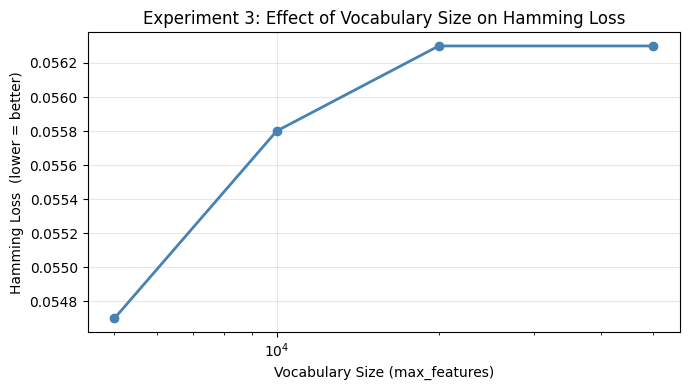

Saved: exp3_vocab_tuning.png


In [57]:

print("Running Experiment 3...\n")

best_ngram = (1, 2) if results_exp2['Hamming Loss'] < results_exp1['Hamming Loss'] else (1, 1)
print(f"Using ngram_range={best_ngram} (winner from Exp 1 vs 2)\n")

vocab_sizes = [5000, 10000, 20000, 50000]
exp3_rows = []

for size in vocab_sizes:
    print(f"Testing max_features={size:,}...", end=' ')

    vec = TfidfVectorizer(
        max_features=size,  
        min_df=2,
        max_df=0.95,
        lowercase=False,
        sublinear_tf=True,
        ngram_range=best_ngram,
    )
    Xtr = vec.fit_transform(X_train)
    Xvl = vec.transform(X_val)

    model = OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        n_jobs=-1
    )
    model.fit(Xtr, Y_train)
    preds = model.predict(Xvl)

    hl   = hamming_loss(Y_val, preds)
    mf1  = f1_score(Y_val, preds, average='micro', zero_division=0)
    maf1 = f1_score(Y_val, preds, average='macro', zero_division=0)
    print(f"HL={hl:.4f}  MicroF1={mf1:.4f}  MacroF1={maf1:.4f}")

    exp3_rows.append({'vocab_size': size, 'Hamming Loss': round(hl,4),
                      'Micro F1': round(mf1,4), 'Macro F1': round(maf1,4)})

exp3_df = pd.DataFrame(exp3_rows)
print("\n── Vocabulary Size Results ──")
print(exp3_df.to_string(index=False))


best_row       = exp3_df.loc[exp3_df['Hamming Loss'].idxmin()]
BEST_VOCAB     = int(best_row['vocab_size'])
print(f"\nbest vocabulary size: {BEST_VOCAB:,}  (Hamming Loss = {best_row['Hamming Loss']})")

# record the best result
results_exp3 = {
    'Experiment':      f'Exp 3: LR + vocab={BEST_VOCAB:,}',
    'Hamming Loss':    best_row['Hamming Loss'],
    'Micro F1':        best_row['Micro F1'],
    'Macro F1':        best_row['Macro F1'],
    'Subset Accuracy': None
}
all_results.append(results_exp3)

# Plot vocab size vs Hamming Loss 
plt.figure(figsize=(7, 4))
plt.plot(exp3_df['vocab_size'], exp3_df['Hamming Loss'],
         marker='o', color='steelblue', linewidth=2)
plt.xlabel('Vocabulary Size (max_features)')
plt.ylabel('Hamming Loss  (lower = better)')
plt.title('Experiment 3: Effect of Vocabulary Size on Hamming Loss')
plt.xscale('log')   # log scale: 5k→10k→20k→50k spaced evenly visually
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp3_vocab_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exp3_vocab_tuning.png")

---
## Experiment 4 Model Comparison: LR vs SVM vs Random Forest

**What changed:** Replace Logistic Regression with two alternative classifiers

**Why:** LR established our baseline. But different algorithms make different assumptions:
- **LR** finds a probabilistic hyperplane  works well when classes are linearly separable
- **LinearSVC** finds the MAXIMUM MARGIN hyperplane often stronger on high-dimensional sparse text data because it focuses on the hardest-to-classify examples (the 'support vectors')
- **Random Forest** builds many decision trees and votes captures non-linear patterns but may struggle with sparse high-dimensional text

We use the best TF-IDF config from Experiment 3 for a fair comparison.

Running Experiment 4 — Model Comparison...

Using TF-IDF: vocab=5,000, ngrams=(1, 1)

Training: LR (best config)...

════════════════════════════════════════════════════
  Exp 4: LR (best config)
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0547
  Micro F1          (↑ higher=better): 0.4297
  Macro F1          (↑ higher=better): 0.2385
  Subset Accuracy   (↑ higher=better): 0.2638
════════════════════════════════════════════════════
Training: LinearSVC...

════════════════════════════════════════════════════
  Exp 4: LinearSVC
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0450
  Micro F1          (↑ higher=better): 0.6156
  Macro F1          (↑ higher=better): 0.5149
  Subset Accuracy   (↑ higher=better): 0.3823
════════════════════════════════════════════════════
Training: Random Forest...

════════════════════════════════════════════════════
  Exp 4: Random Forest
════════════════════════

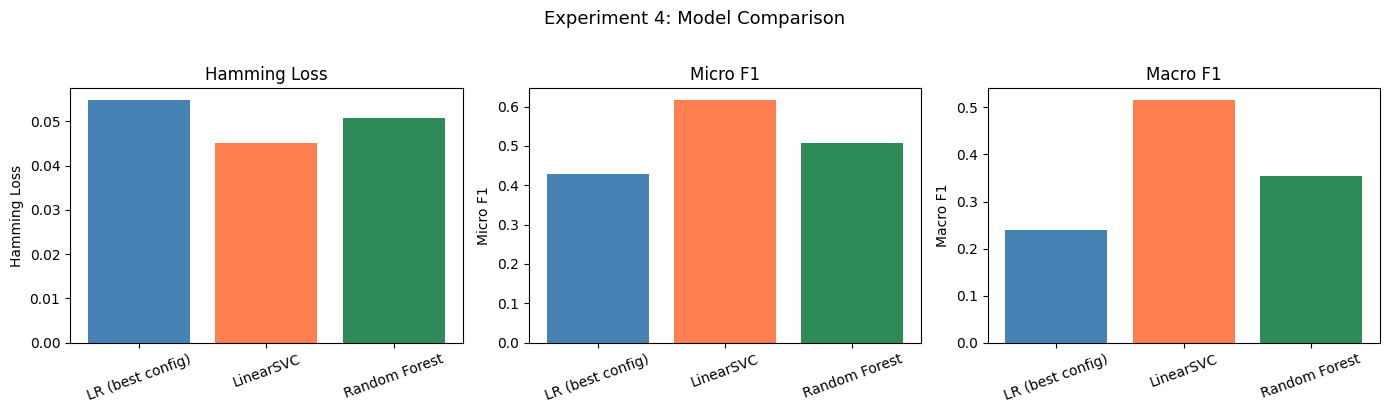

saved: exp4_model_comparison.png

best model in Exp 4: Exp 4: LinearSVC
insight: Why did that model win? Consider: SVM is known to excel on sparse high-dim text.


In [58]:
print("Running Experiment 4 — Model Comparison...\n")

tfidf_best = TfidfVectorizer(
    max_features=BEST_VOCAB,
    min_df=2,
    max_df=0.95,
    lowercase=False,
    sublinear_tf=True,
    ngram_range=best_ngram,
)
X_train_best = tfidf_best.fit_transform(X_train)
X_val_best   = tfidf_best.transform(X_val)
print(f"Using TF-IDF: vocab={BEST_VOCAB:,}, ngrams={best_ngram}\n")

models = {

    "LR (best config)": OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        n_jobs=-1
    ),

    "LinearSVC": OneVsRestClassifier(
        LinearSVC(
            C=1.0,

            max_iter=2000,

            random_state=42,
        ),
        n_jobs=-1
    ),

    "Random Forest": OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=100,
            min_samples_split=5,
            n_jobs=-1,
            random_state=42,
        ),
        n_jobs=1
        
    ),
}

#train and evaluate all three 
exp4_results = []
for name, model in models.items():
    print(f"Training: {name}...")
    model.fit(X_train_best, Y_train)
    preds  = model.predict(X_val_best)
    result = evaluate(Y_val, preds, f"Exp 4: {name}")
    exp4_results.append(result)
    all_results.append(result)

# comparison plot 
exp4_df = pd.DataFrame(exp4_results)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'coral', 'seagreen']

for ax, metric in zip(axes, ['Hamming Loss', 'Micro F1', 'Macro F1']):
    short_names = [r.replace('Exp 4: ','') for r in exp4_df['Experiment']]
    ax.bar(short_names, exp4_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Experiment 4: Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('exp4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: exp4_model_comparison.png")

winner = exp4_df.loc[exp4_df['Hamming Loss'].idxmin(), 'Experiment']
print(f"\nbest model in Exp 4: {winner}")
print("insight: Why did that model win? Consider: SVM is known to excel on sparse high-dim text.")

---
## Experiment 5 Threshold Optimization

**What changed:** Replace fixed threshold (0.5) with an optimized per-label threshold

**Why:** By default, a label is predicted as 1 if the model's probability score ≥ 0.5.  
But for rare labels, the model may only ever produce probabilities of 0.2–0.3, so it always predicts 0 for them (false negatives). We can find the threshold per label that maximizes F1 on the validation set.

**Note:** `LinearSVC` doesn't output probabilities  we use `LogisticRegression` here because `.predict_proba()` is required.

In [59]:
print("Running Experiment 5 — Threshold Optimization...\n")

lr_proba = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    n_jobs=-1
)
lr_proba.fit(X_train_best, Y_train)
Y_val_proba = lr_proba.predict_proba(X_val_best)

print(f"Probability matrix shape: {Y_val_proba.shape}")
print(f"Sample probabilities (doc 0): {Y_val_proba[0].round(3)}")


Y_pred_default = (Y_val_proba >= 0.5).astype(int)
hl_default = hamming_loss(Y_val, Y_pred_default)
print(f"\n Hamming Loss with default threshold (0.5): {hl_default:.4f}")
thresholds_to_try = np.linspace(0.1, 0.9, 50)

best_thresholds = []

for j in range(Y.shape[1]):
    label_probs = Y_val_proba[:, j]
    label_true  = Y_val[:, j]

    best_f1, best_t = 0, 0.5  # start with defaults

    for t in thresholds_to_try:
        preds = (label_probs >= t).astype(int)
        f1    = f1_score(label_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    best_thresholds.append(round(best_t, 3))

print("\nOptimal threshold per label:")
for label, thresh in zip(LABEL_NAMES, best_thresholds):
    flag = "  ← significantly different from 0.5" if abs(thresh - 0.5) > 0.15 else ""
    print(f"  {label:<12}: {thresh:.3f}{flag}")

#apply optimized thresholds 
Y_pred_opt = np.zeros_like(Y_val_proba, dtype=int)

for j, t in enumerate(best_thresholds):
    Y_pred_opt[:, j] = (Y_val_proba[:, j] >= t).astype(int)

results_exp5 = evaluate(Y_val, Y_pred_opt, "Exp 5: LR + Optimized Thresholds")
all_results.append(results_exp5)

print(f"\nHamming Loss: default={hl_default:.4f} → optimized={results_exp5['Hamming Loss']:.4f}")
print("insight: Labels with thresholds far from 0.5 reveal which labels are hard to calibrate.")

Running Experiment 5 — Threshold Optimization...

Probability matrix shape: (599, 27)
Sample probabilities (doc 0): [0.04  0.015 0.041 0.014 0.017 0.016 0.011 0.006 0.013 0.98  0.009 0.011
 0.007 0.006 0.016 0.012 0.083 0.02  0.009 0.014 0.008 0.008 0.013 0.024
 0.028 0.04  0.016]

 Hamming Loss with default threshold (0.5): 0.0547

Optimal threshold per label:
  3.1.1 - Maternal mortality ratio: 0.165  ← significantly different from 0.5
  3.1.2 - Proportion of births attended by skilled health personnel: 0.100  ← significantly different from 0.5
  3.2.1 - Under-5 mortality rate: 0.133  ← significantly different from 0.5
  3.2.2 - Neonatal mortality rate: 0.133  ← significantly different from 0.5
  3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations: 0.198  ← significantly different from 0.5
  3.3.2 - Tuberculosis incidence per 100,000 population: 0.116  ← significantly different from 0.5
  3.3.3 - Malaria incidence per 1,000 population

---
## Experiment 6  Class Imbalance: `class_weight='balanced'`

**What changed:** Add `class_weight='balanced'` to Logistic Regression

**Why:** Person A's EDA (loaded in Section 2) showed significant label imbalance some SDG 3 indicators appear in far fewer documents than others. The model barely sees rare labels during training, so it learns to predict 0 for them almost always. This hurts Macro F1 (which equally weights all labels).

`class_weight='balanced'` tells the model: *"a mistake on a rare label should be penalized more heavily than a mistake on a common label."*

The weight for each class = `total_samples / (n_classes × count_of_this_class)`.  
Rare class → small count → larger weight → mistakes are penalized more.

**Expected tradeoff:** Macro F1 should improve. Hamming Loss might slightly worsen (more false positives on rare labels). This tradeoff is a key discussion point.

In [60]:

print("Running Experiment 6 — Class Imbalance Handling...\n")

lr_balanced = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
    ),
    n_jobs=-1
)
lr_balanced.fit(X_train_best, Y_train)
Y_pred_bal = lr_balanced.predict(X_val_best)
results_6a = evaluate(Y_val, Y_pred_bal, "Exp 6A: LR + class_weight=balanced")
all_results.append(results_6a)


Y_proba_bal = lr_balanced.predict_proba(X_val_best)


best_thresh_bal = []
for j in range(Y.shape[1]):
    label_probs = Y_proba_bal[:, j]
    label_true  = Y_val[:, j]
    best_f1, best_t = 0, 0.5
    for t in thresholds_to_try:
        preds = (label_probs >= t).astype(int)
        f1    = f1_score(label_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh_bal.append(round(best_t, 3))

Y_pred_bal_opt = np.zeros_like(Y_proba_bal, dtype=int)
for j, t in enumerate(best_thresh_bal):
    Y_pred_bal_opt[:, j] = (Y_proba_bal[:, j] >= t).astype(int)

results_6b = evaluate(Y_val, Y_pred_bal_opt, "Exp 6B: LR + balanced + opt thresholds")
all_results.append(results_6b)

print("\n  Macro F1 (key metric for rare label performance)  ")
print(f"  Exp 1 (no balancing):             {results_exp1['Macro F1']:.4f}")
print(f"  Exp 6A (balanced weights):        {results_6a['Macro F1']:.4f}")
print(f"  Exp 6B (balanced + opt thresh):   {results_6b['Macro F1']:.4f}")

print("\n Hamming Loss comparison ")
print(f"  Exp 1 (no balancing):             {results_exp1['Hamming Loss']:.4f}")
print(f"  Exp 6A (balanced weights):        {results_6a['Hamming Loss']:.4f}")
print(f"  Exp 6B (balanced + opt thresh):   {results_6b['Hamming Loss']:.4f}")

print("\nKEY INSIGHT FOR REPORT:")
print("If Macro F1 improved but Hamming Loss worsened → balancing trades overall accuracy")
print("for better rare-label recall. Discuss this tradeoff explicitly in Section 7.")

Running Experiment 6 — Class Imbalance Handling...


════════════════════════════════════════════════════
  Exp 6A: LR + class_weight=balanced
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0623
  Micro F1          (↑ higher=better): 0.6221
  Macro F1          (↑ higher=better): 0.5684
  Subset Accuracy   (↑ higher=better): 0.2721
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  Exp 6B: LR + balanced + opt thresholds
════════════════════════════════════════════════════
  Hamming Loss      (↓ lower=better) : 0.0514
  Micro F1          (↑ higher=better): 0.6672
  Macro F1          (↑ higher=better): 0.6251
  Subset Accuracy   (↑ higher=better): 0.3356
════════════════════════════════════════════════════

  Macro F1 (key metric for rare label performance)  
  Exp 1 (no balancing):             0.2680
  Exp 6A (balanced weights):        0.5684
  Exp 6B (balanced + opt thresh):   0.6251

---
# SECTION 6  full results table + visualizations

In [61]:
results_df = pd.DataFrame(all_results).dropna(subset=['Hamming Loss'])
results_df = results_df.sort_values('Hamming Loss').reset_index(drop=True)

print("\n" + "═"*90)
print("  COMPLETE EXPERIMENT RESULTS  (sorted by Hamming Loss, lowest = best)")
print("═"*90)
print(results_df.to_string(index=False))
print("═"*90)

results_df.to_csv('experiment_results.csv', index=False)
print("\n Saved: experiment_results.csv")


══════════════════════════════════════════════════════════════════════════════════════════
  COMPLETE EXPERIMENT RESULTS  (sorted by Hamming Loss, lowest = best)
══════════════════════════════════════════════════════════════════════════════════════════
                            Experiment  Hamming Loss  Micro F1  Macro F1  Subset Accuracy
                      Exp 4: LinearSVC        0.0450    0.6156    0.5149           0.3823
      Exp 5: LR + Optimized Thresholds        0.0506    0.6592    0.5407           0.3306
                  Exp 4: Random Forest        0.0507    0.5066    0.3532           0.2838
Exp 6B: LR + balanced + opt thresholds        0.0514    0.6672    0.6251           0.3356
Exp 1: LR + TF-IDF Unigrams (Baseline)        0.0543    0.4398    0.2680           0.2554
               Exp 3: LR + vocab=5,000        0.0547    0.4297    0.2385              NaN
               Exp 4: LR (best config)        0.0547    0.4297    0.2385           0.2638
            Exp 2: LR + TF

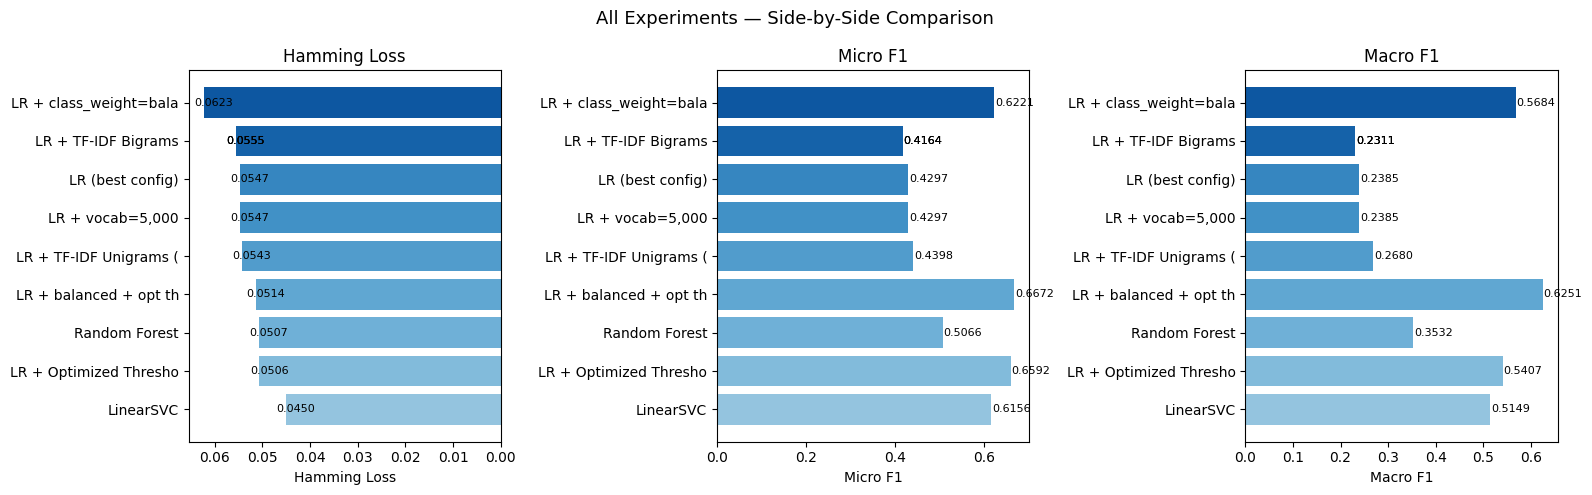

Saved: all_experiments_comparison.png


In [62]:
plot_df = results_df.copy()
short_labels = [
    name.replace('Exp ', 'E').split(':')[-1].strip()[:22]
    for name in plot_df['Experiment']
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(plot_df)))

for ax, metric in zip(axes, ['Hamming Loss', 'Micro F1', 'Macro F1']):
    bars = ax.barh(short_labels, plot_df[metric], color=palette)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    if metric == 'Hamming Loss':
        ax.invert_xaxis()  # flip: best (lowest) reads as 'furthest right'
    # Add value labels on bars
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('All Experiments — Side-by-Side Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('all_experiments_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_experiments_comparison.png")

Best experiment: Exp 4: LinearSVC
Generating per-label F1 breakdown...

                                                                                                                                                                                                                                                                                                                                     Label     F1  Support
                                                                                                                                                                                                                                     3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations 0.8790       78
                                                                                                                                                                                                                                          

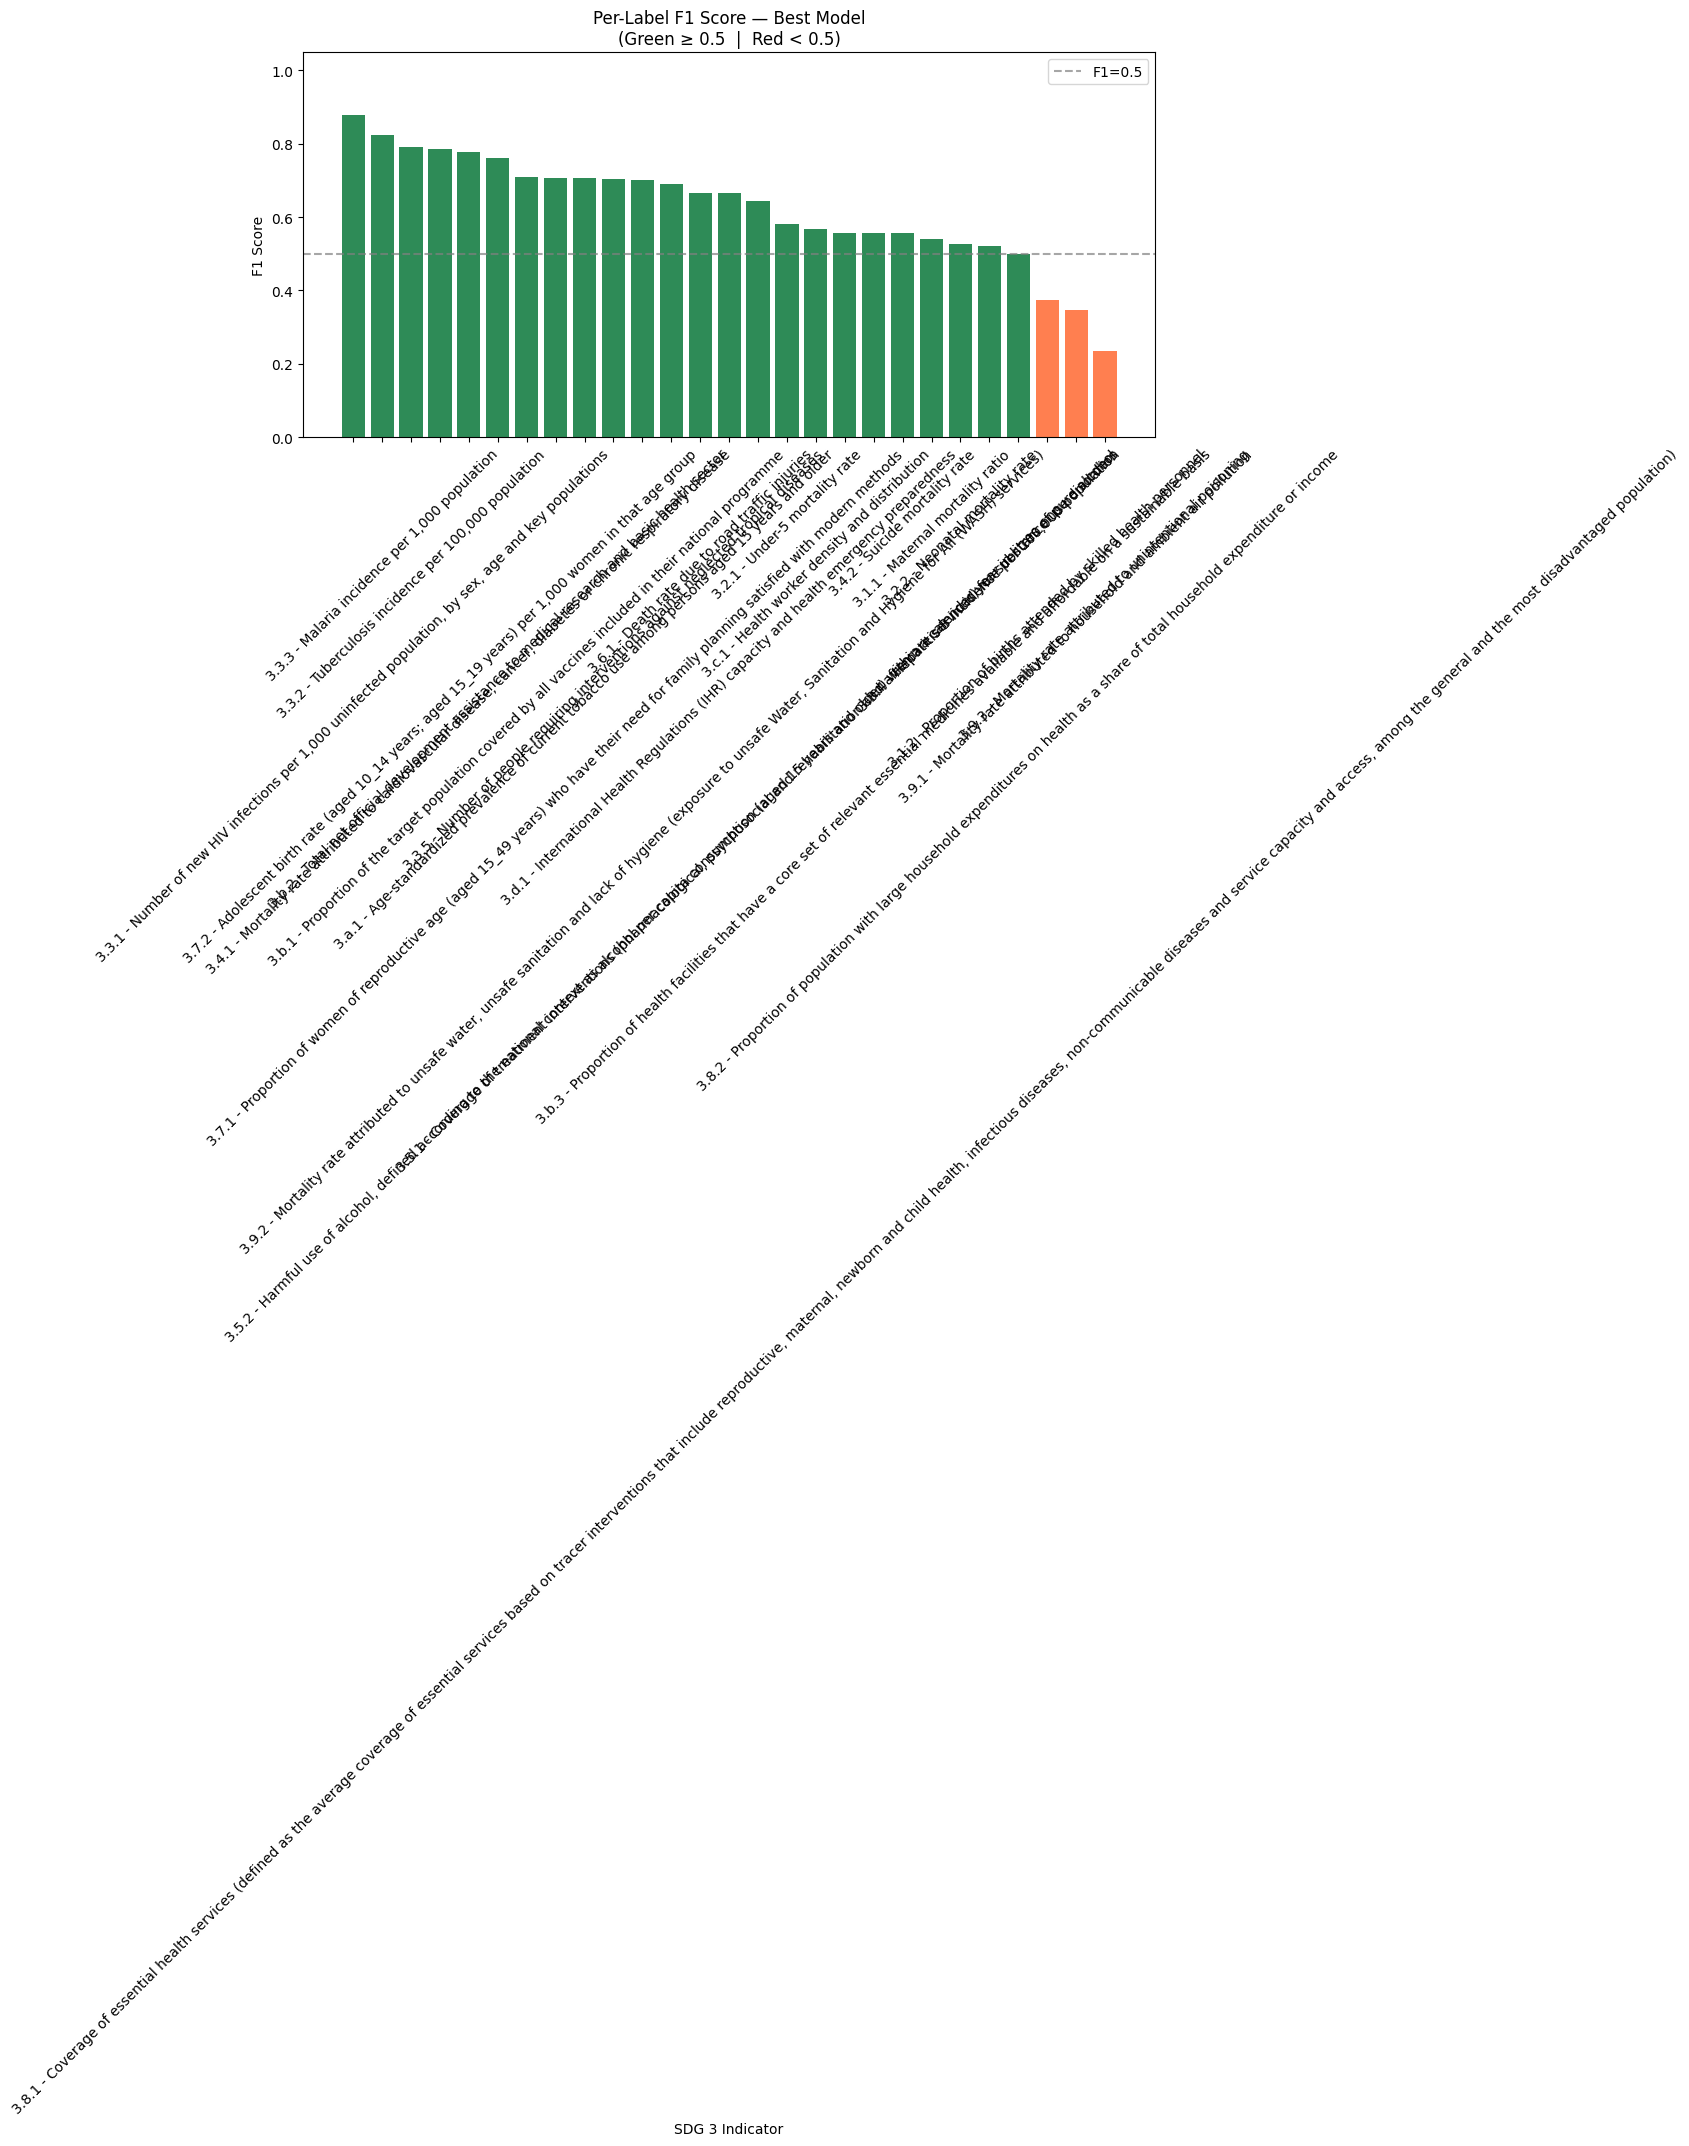

saved: per_label_f1.png

 Labels with F1 < 0.4 (hardest to predict): ['3.1.2 - Proportion of births attended by skilled health personnel', '3.9.1 - Mortality rate attributed to household and ambient air pollution', '3.9.3 - Mortality rate attributed to unintentional poisoning']
→ Cross-reference these with Person A's rarest labels. Low support usually = low F1.


In [64]:
best_exp_name = results_df.iloc[0]['Experiment']
print(f"Best experiment: {best_exp_name}")
print("Generating per-label F1 breakdown...\n")

best_preds = Y_pred_bal_opt

per_label_f1 = f1_score(Y_val, best_preds, average=None, zero_division=0)

per_label_df = pd.DataFrame({
    'Label':   LABEL_NAMES,
    'F1':      per_label_f1.round(4),
    'Support': Y_val.sum(axis=0).astype(int),
}).sort_values('F1', ascending=False)

print(per_label_df.to_string(index=False))

colors = ['seagreen' if f >= 0.5 else 'coral' for f in per_label_df['F1']]
plt.figure(figsize=(11, 5))
plt.bar(per_label_df['Label'], per_label_df['F1'], color=colors)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='F1=0.5')
plt.title('Per-Label F1 Score — Best Model\n(Green ≥ 0.5  |  Red < 0.5)')
plt.xlabel('SDG 3 Indicator')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('per_label_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: per_label_f1.png")

low_f1_labels = per_label_df[per_label_df['F1'] < 0.4]['Label'].tolist()
print(f"\n Labels with F1 < 0.4 (hardest to predict): {low_f1_labels}")
print("→ Cross-reference these with Person A's rarest labels. Low support usually = low F1.")

---
# SECTION 7  Final Test Predictions

Now we apply the best model to the actual test set (`devex_test_clean.csv`).  
The test set has no labels  our predictions are the final deliverable.

**Important:** We retrain on the FULL training data (not just the 80% split) before predicting on test. More training data = better model.

In [66]:
print("Retraining best model on 100% of labeled data...")

tfidf_final = TfidfVectorizer(
    max_features=BEST_VOCAB,
    min_df=2,
    max_df=0.95,
    lowercase=False,
    sublinear_tf=True,
    ngram_range=best_ngram,
)
X_all_tfidf  = tfidf_final.fit_transform(X_raw)

X_test_tfidf = tfidf_final.transform(test_df['clean_text'].values)
print(f"Full training matrix shape: {X_all_tfidf.shape}")
print(f"Test matrix shape:          {X_test_tfidf.shape}")

final_model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        class_weight='balanced',  # keep best config from Experiment 6
    ),
    n_jobs=-1
)
final_model.fit(X_all_tfidf, Y)
print("Final model trained on full data. ")

Y_test_proba = final_model.predict_proba(X_test_tfidf)

Y_test_pred = np.zeros_like(Y_test_proba, dtype=int)
for j, t in enumerate(best_thresh_bal):
    Y_test_pred[:, j] = (Y_test_proba[:, j] >= t).astype(int)


empty_docs = (Y_test_pred.sum(axis=1) == 0).sum()
for i in range(len(Y_test_pred)):
    if Y_test_pred[i].sum() == 0:
        best_j = np.argmax(Y_test_proba[i])
        Y_test_pred[i, best_j] = 1

print(f"Documents that had 0 labels (corrected): {empty_docs}")
print(f"All documents now have ≥ 1 label: {(Y_test_pred.sum(axis=1) > 0).all()}")

preds_df = pd.DataFrame(Y_test_pred, columns=LABEL_NAMES)

id_candidates = [c for c in test_df.columns
                    if 'id' in c.lower() and c not in ['clean_text', RAW_TEXT_COL]]
if id_candidates:
    preds_df.insert(0, id_candidates[0], test_df[id_candidates[0]].values)
    print(f"Included ID column: '{id_candidates[0]}'")

preds_df.to_csv('test_predictions.csv', index=False)
print(f"\nsaved: test_predictions.csv")
print(f"Shape: {preds_df.shape}")
print("\nFirst 5 predictions:")
print(preds_df.head())

Retraining best model on 100% of labeled data...
Full training matrix shape: (2995, 5000)
Test matrix shape:          (998, 5000)
Final model trained on full data. 
Documents that had 0 labels (corrected): 31
All documents now have ≥ 1 label: True
Included ID column: 'Unique ID'

saved: test_predictions.csv
Shape: (998, 28)

First 5 predictions:
   Unique ID  3.1.1 - Maternal mortality ratio  \
0      49848                                 0   
1      52348                                 0   
2     103541                                 0   
3      52382                                 0   
4      47212                                 0   

   3.1.2 - Proportion of births attended by skilled health personnel  \
0                                                  0                   
1                                                  0                   
2                                                  0                   
3                                                  0           

In [ ]:
#final notebook summary 
print("\n" + "█"*65)
print("  PERSON B — NOTEBOOK COMPLETE")
print("█"*65)
print("""
WHAT THIS NOTEBOOK DOES:
  Continues directly from Person A's devex_train_clean.csv and
  devex_test_clean.csv — no reprocessing of raw data.

EXPERIMENTS COMPLETED:
  Exp 1  Baseline: LR + TF-IDF Unigrams
  Exp 2  LR + TF-IDF Bigrams
  Exp 3  Vocabulary size tuning {5k, 10k, 20k, 50k}
  Exp 4  Model comparison: LR vs LinearSVC vs Random Forest
  Exp 5  Threshold optimization (per-label)
  Exp 6A LR + class_weight='balanced'
  Exp 6B LR + balanced + optimized thresholds

OUTPUT FILES:
  experiment_results.csv         ← all experiment metrics
  test_predictions.csv           ← final predictions for test set
  exp3_vocab_tuning.png          ← vocab size vs Hamming Loss
  exp4_model_comparison.png      ← LR vs SVM vs RF comparison
  all_experiments_comparison.png ← all 7 experiments side-by-side
  per_label_f1.png               ← per-SDG-indicator F1 breakdown

HAND OFF TO:
  Person C — receives experiment_results.csv as the baseline to beat
             with advanced embeddings (BERT, Word2Vec, etc.)
  Person D — receives all .png files and experiment_results.csv
             for the Results and Discussion sections of the report
""")


█████████████████████████████████████████████████████████████████
  PERSON B — NOTEBOOK COMPLETE
█████████████████████████████████████████████████████████████████

WHAT THIS NOTEBOOK DOES:
  Continues directly from Person A's devex_train_clean.csv and
  devex_test_clean.csv — no reprocessing of raw data.

EXPERIMENTS COMPLETED:
  Exp 1  Baseline: LR + TF-IDF Unigrams
  Exp 2  LR + TF-IDF Bigrams
  Exp 3  Vocabulary size tuning {5k, 10k, 20k, 50k}
  Exp 4  Model comparison: LR vs LinearSVC vs Random Forest
  Exp 5  Threshold optimization (per-label)
  Exp 6A LR + class_weight='balanced'
  Exp 6B LR + balanced + optimized thresholds

OUTPUT FILES:
  experiment_results.csv         ← all experiment metrics
  test_predictions.csv           ← final predictions for test set
  exp3_vocab_tuning.png          ← vocab size vs Hamming Loss
  exp4_model_comparison.png      ← LR vs SVM vs RF comparison
  all_experiments_comparison.png ← all 7 experiments side-by-side
  per_label_f1.png             